## 7.8 분자 해밀토니안 — 패리티 변환

In [1]:
# 필요한 모듈 임포트
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_city, plot_state_qsphere, plot_state_paulivec
from qiskit.quantum_info import partial_trace, Statevector
from qiskit_aer import AerSimulator, StatevectorSimulator  # 상태벡터 획득용 StatevectorSimulator
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# H₂ 분자 해밀토니안 정의 (단순 예시)
# 패리티 변환으로 표현한 H2 분자 해밀토니안 (큐비트 연산자)
coeffs = [-0.8105479805373267, 0.17218393261915543, -0.22575349222402502, 0.12091263261776641, 0.16892753870087907]
pauli_strings = ['II', 'ZI', 'IZ', 'ZZ', 'XX']

In [3]:
# 해밀토니안의 sparse 파울리 연산자 생성
H2_hamiltonian = SparsePauliOp.from_list([(pauli_strings[i], coeffs[i]) for i in range(len(coeffs))])

In [4]:
# 패리티 변환으로 이 해밀토니안을 시뮬레이션할 양자회로 생성
num_qubits = 2
qc = QuantumCircuit(num_qubits)

In [5]:
# 초기 상태 적용 (예: 하트리-폭 상태)
qc.x(0)
qc.x(1)

In [6]:
# 분자 해밀토니안 진화를 위한 연산 적용
qc.h(0)            # 중첩 생성을 위한 하다마드 게이트
qc.cx(0, 1)        # 상호작용 항을 위한 CNOT 게이트
qc.rx(np.pi/4, 0)  # 해밀토니안 진화 일부를 모사하는 회전
qc.rx(np.pi/4, 1)  # 큐비트 1에 대한 회전

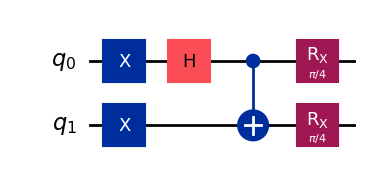

In [7]:
# MPL로 회로 그리기
qc.draw(output='mpl')
plt.show()

In [8]:
# StatevectorSimulator로 회로 시뮬레이션
simulator = StatevectorSimulator()  # 상태벡터 획득용

In [9]:
# 시뮬레이터용으로 회로 트랜스파일
tqc = transpile(qc, simulator)

In [10]:
# 시뮬레이션 실행
result = simulator.run(tqc).result()

In [11]:
# 최종 상태벡터 획득
state = result.get_statevector(tqc)

<Figure size 640x480 with 0 Axes>

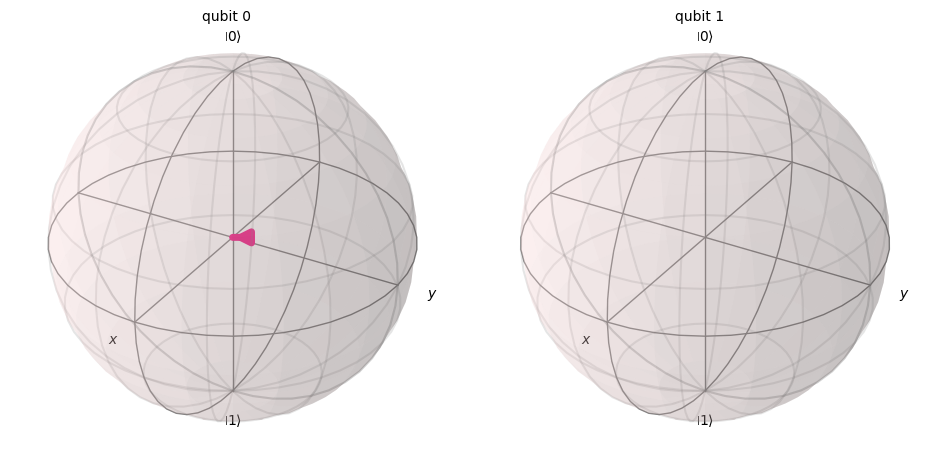

In [12]:
# 블로흐 다중벡터로 상태 시각화
fig = plt.figure()
plot_bloch_multivector(state)
plt.show()

/opt/miniconda3/envs/qml/lib/python3.10/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))


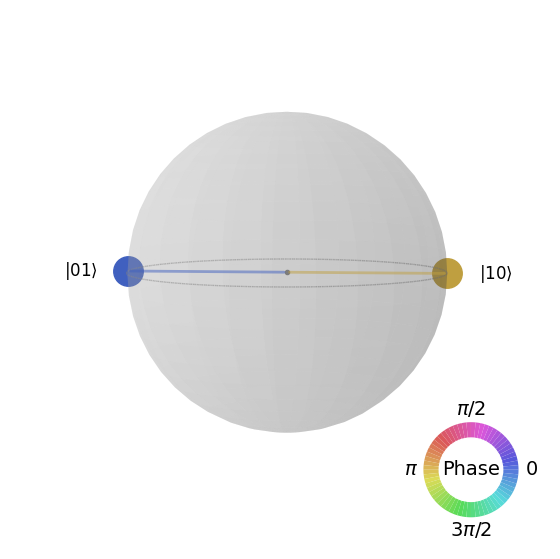

In [13]:
# QSphere로 상태 시각화
plot_state_qsphere(state)
plt.show()

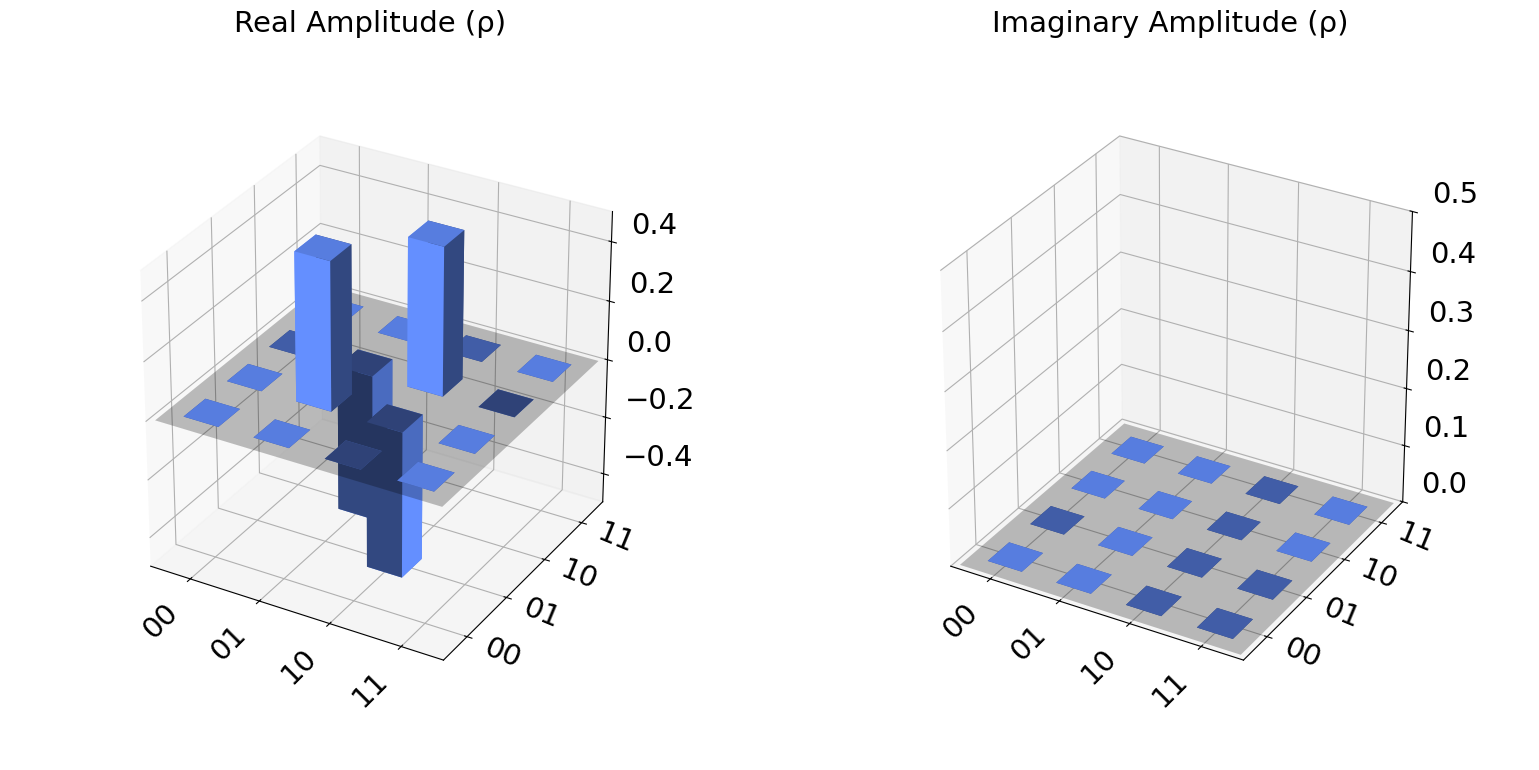

In [14]:
# state city 플롯으로 상태 시각화
plot_state_city(state)
plt.show()

/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from

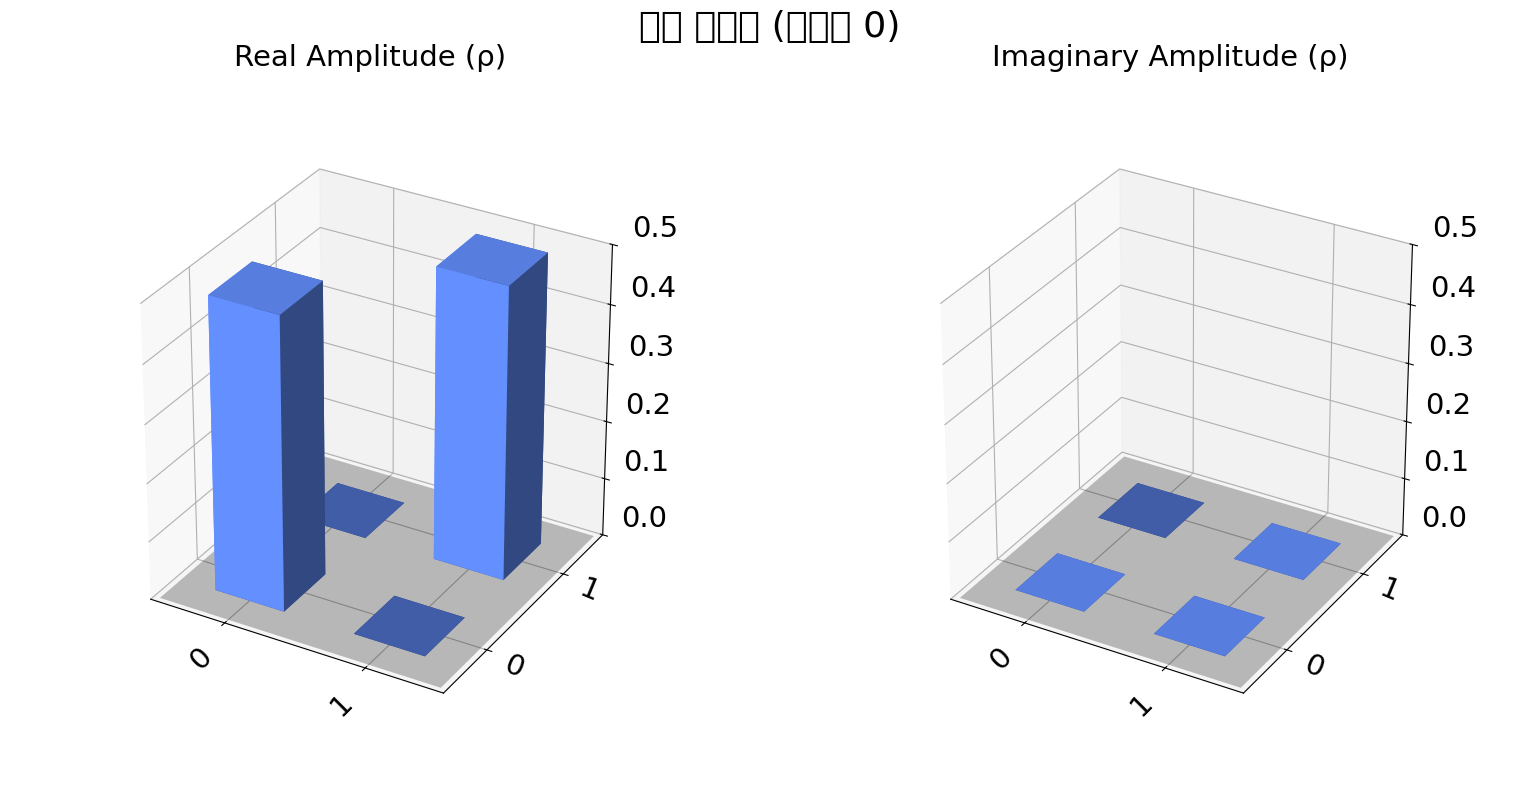

In [15]:
# 부분 대각합 시각화 (한 큐비트 추적 제거)
rho = partial_trace(state, [1])  # 두 번째 큐비트 추적 제거
plot_state_city(rho, title="부분 대각합 (큐비트 0)")
plt.show()

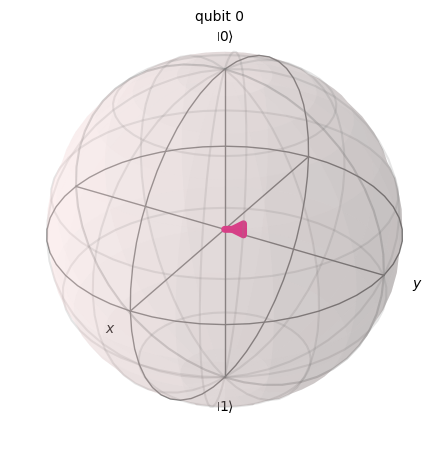

In [16]:
# 부분 대각합으로 큐비트 수 축소 (예: 큐비트 1 추적 제거)
reduced_density_matrix = partial_trace(state, [1])

# 축소 상태를 블로흐 다중벡터로 시각화
plot_bloch_multivector(reduced_density_matrix)
plt.show()

/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50872 (\N{HANGUL SYLLABLE UL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48289 (\N{HANGUL SYLLABLE BEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from f

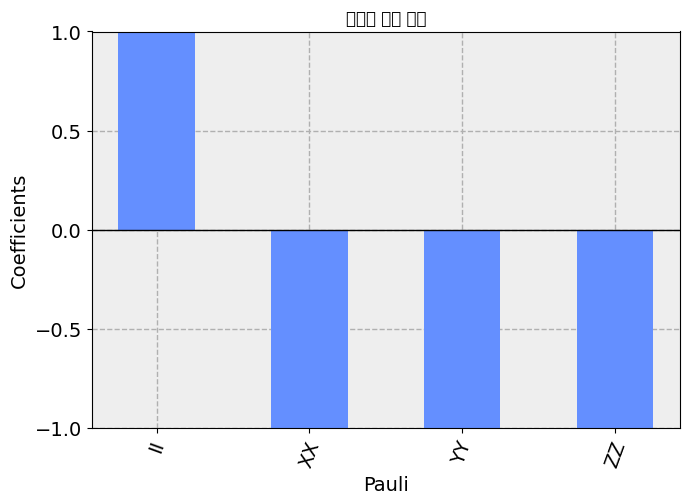

In [17]:
# 파울리 벡터 시각화
plot_state_paulivec(state)
plt.title("파울리 벡터 표현")
plt.show()

In [18]:
# 측정 추가 (모든 큐비트)
qc.measure_all()

In [19]:
# 측정 포함 회로 트랜스파일 및 실행
tqc_measure = transpile(qc, simulator)
result_measure = simulator.run(tqc_measure).result()
counts = result_measure.get_counts(tqc_measure)

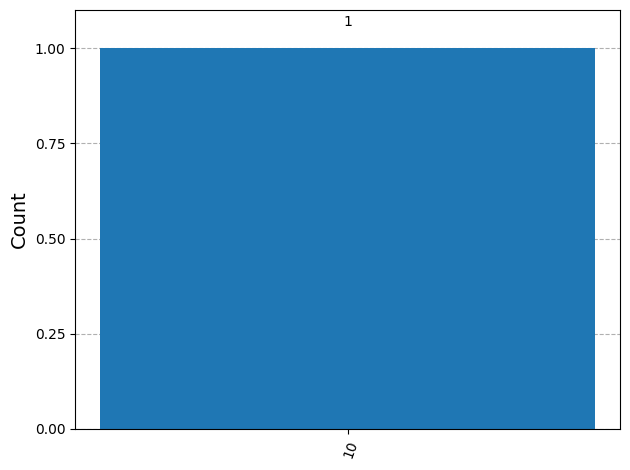

In [20]:
# 측정 결과를 히스토그램으로 시각화
plot_histogram(counts)
plt.show()